<a href="https://colab.research.google.com/github/14marcos1/pibicjr/blob/main/kaggle_mortalidade_30-06-2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pipeline 2.1 — Mortalidade SIM/DATASUS por UF e Região

Este notebook refatora o processamento anterior para remover repetição de código, manter as 27 unidades federativas, agregar resultados por região e gerar saídas consolidadas para análise temporal.

A lógica epidemiológica foi preservada:
- **Neoplasias:** CID-10 iniciadas por `C` e códigos `D00–D48`;
- **Doenças do aparelho circulatório:** CID-10 iniciadas por `I`;
- os demais códigos são classificados como `Outros` e excluídos dos resumos finais.

In [ ]:
# Instalação das bibliotecas necessárias no Kaggle
!pip install pyreaddbc dbfread -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 kB 1.0 MB/s eta 0:00:00a 0:00:01


In [ ]:
import os
from pathlib import Path
from urllib.request import urlretrieve

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
except ImportError:
    sns = None

from pyreaddbc import dbc2dbf
from dbfread import DBF

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 50)

## 1. Configurações gerais

O processamento usa todas as 27 UFs brasileiras e cria uma coluna `REGIAO`, permitindo comparar o crescimento por região.

In [ ]:
ANOS = range(2010, 2024)

UF_REGIAO = {
    "AC": "Norte", "AP": "Norte", "AM": "Norte", "PA": "Norte", "RO": "Norte", "RR": "Norte", "TO": "Norte",
    "AL": "Nordeste", "BA": "Nordeste", "CE": "Nordeste", "MA": "Nordeste", "PB": "Nordeste",
    "PE": "Nordeste", "PI": "Nordeste", "RN": "Nordeste", "SE": "Nordeste",
    "DF": "Centro-Oeste", "GO": "Centro-Oeste", "MT": "Centro-Oeste", "MS": "Centro-Oeste",
    "ES": "Sudeste", "MG": "Sudeste", "RJ": "Sudeste", "SP": "Sudeste",
    "PR": "Sul", "RS": "Sul", "SC": "Sul"
}

ESTADOS = list(UF_REGIAO.keys())

PASTA_BASE = Path("/kaggle/working/dados_sus")
PASTA_SAIDA = Path("/kaggle/working/outputs")
PASTA_FIGURAS = PASTA_SAIDA / "figuras"

PASTA_BASE.mkdir(parents=True, exist_ok=True)
PASTA_SAIDA.mkdir(parents=True, exist_ok=True)
PASTA_FIGURAS.mkdir(parents=True, exist_ok=True)

print(f"Total de UFs: {len(ESTADOS)}")
print(pd.Series(UF_REGIAO).value_counts().sort_index())

Total de UFs: 27
Centro-Oeste    4
Nordeste        9
Norte           7
Sudeste         4
Sul             3
Name: count, dtype: int64


## 2. Funções reutilizáveis

As funções abaixo fazem download, conversão, leitura, classificação CID-10 e sumarização.  
Elas também registram falhas para gerar um log de arquivos ausentes ou com erro.

In [ ]:
def montar_url_datasus(uf: str, ano: int) -> str:
    """Monta a URL do arquivo DBC de mortalidade do SIM/DATASUS."""
    nome = f"DO{uf}{ano}.dbc"
    return f"ftp://ftp.datasus.gov.br/dissemin/publicos/SIM/CID10/DORES/{nome}"


def baixar_arquivo(url: str, destino: Path) -> tuple[bool, str]:
    """Baixa um arquivo se ele ainda não existir."""
    if destino.exists() and destino.stat().st_size > 0:
        return True, "arquivo já existia"
    try:
        urlretrieve(url, destino)
        if destino.exists() and destino.stat().st_size > 0:
            return True, "download concluído"
        return False, "arquivo vazio após download"
    except Exception as e:
        return False, str(e)


def ler_dbc(caminho_dbc: Path) -> pd.DataFrame | None:
    """Converte DBC para DBF, lê o DBF e remove o arquivo temporário."""
    caminho_dbf = caminho_dbc.with_suffix(".dbf")
    try:
        dbc2dbf(str(caminho_dbc), str(caminho_dbf))
        df = pd.DataFrame(iter(DBF(str(caminho_dbf), encoding="latin1")))
        return df
    except Exception as e:
        print(f"Erro ao ler {caminho_dbc.name}: {e}")
        return None
    finally:
        if caminho_dbf.exists():
            try:
                os.remove(caminho_dbf)
            except Exception:
                pass


def classificar_causa(causa) -> str:
    """Classifica a causa básica segundo a lógica usada no notebook original."""
    if pd.isna(causa):
        return "Outros"
    c = str(causa).upper().strip()
    if c.startswith("C"):
        return "Neoplasias"
    if c.startswith("D"):
        try:
            numero = int(c[1:3])
            if 0 <= numero <= 48:
                return "Neoplasias"
        except Exception:
            pass
    if c.startswith("I"):
        return "Aparelho Circulatório"
    return "Outros"


def processar_uf_ano(uf: str, ano: int) -> tuple[pd.DataFrame | None, dict]:
    """Processa um arquivo UF/ano e retorna resumo ou log de erro."""
    nome = f"DO{uf}{ano}.dbc"
    url = montar_url_datasus(uf, ano)
    caminho_dbc = PASTA_BASE / nome

    log = {
        "UF": uf,
        "REGIAO": UF_REGIAO[uf],
        "ANO": ano,
        "ARQUIVO": nome,
        "URL": url,
        "STATUS": "",
        "MENSAGEM": ""
    }

    ok, msg = baixar_arquivo(url, caminho_dbc)
    if not ok:
        log["STATUS"] = "falha_download"
        log["MENSAGEM"] = msg
        return None, log

    df = ler_dbc(caminho_dbc)
    if df is None or df.empty:
        log["STATUS"] = "falha_leitura"
        log["MENSAGEM"] = "arquivo não lido ou vazio"
        return None, log

    if "CAUSABAS" not in df.columns:
        log["STATUS"] = "falha_variavel"
        log["MENSAGEM"] = "variável CAUSABAS ausente"
        return None, log

    df["GRUPO"] = df["CAUSABAS"].apply(classificar_causa)
    resumo = (
        df[df["GRUPO"] != "Outros"]
        .groupby("GRUPO")
        .size()
        .reset_index(name="OBITOS")
    )
    resumo["UF"] = uf
    resumo["REGIAO"] = UF_REGIAO[uf]
    resumo["ANO"] = ano

    log["STATUS"] = "ok"
    log["MENSAGEM"] = f"{len(df):,} registros lidos"
    return resumo[["REGIAO", "UF", "ANO", "GRUPO", "OBITOS"]], log

## 3. Processamento nacional

Esta etapa percorre todas as combinações UF × ano, preservando logs de sucesso e falha.

In [ ]:
resultados = []
logs = []

total = len(ESTADOS) * len(list(ANOS))
contador = 0

for uf in ESTADOS:
    for ano in ANOS:
        contador += 1
        print(f"[{contador}/{total}] Processando {uf} - {ano}")
        resumo, log = processar_uf_ano(uf, ano)
        logs.append(log)
        if resumo is not None:
            resultados.append(resumo)

df_logs = pd.DataFrame(logs)
df_logs.to_csv(PASTA_SAIDA / "logs_processamento.csv", index=False)

if resultados:
    df_uf = pd.concat(resultados, ignore_index=True)
    df_uf = (
        df_uf.groupby(["REGIAO", "UF", "ANO", "GRUPO"], as_index=False)["OBITOS"]
        .sum()
        .sort_values(["REGIAO", "UF", "GRUPO", "ANO"])
    )
    df_uf.to_csv(PASTA_SAIDA / "mortalidade_uf_consolidado.csv", index=False)
    display(df_uf.head())
else:
    raise RuntimeError("Nenhum dado foi processado. Verifique conexão, URLs e permissões do Kaggle.")

[1/378] Processando AC - 2010
[2/378] Processando AC - 2011
[3/378] Processando AC - 2012
[4/378] Processando AC - 2013
[5/378] Processando AC - 2014
[6/378] Processando AC - 2015
[7/378] Processando AC - 2016
[8/378] Processando AC - 2017
[9/378] Processando AC - 2018
[10/378] Processando AC - 2019
[11/378] Processando AC - 2020
[12/378] Processando AC - 2021
[13/378] Processando AC - 2022
[14/378] Processando AC - 2023
[15/378] Processando AP - 2010
[16/378] Processando AP - 2011
[17/378] Processando AP - 2012
[18/378] Processando AP - 2013
[19/378] Processando AP - 2014
[20/378] Processando AP - 2015
[21/378] Processando AP - 2016
[22/378] Processando AP - 2017
[23/378] Processando AP - 2018
[24/378] Processando AP - 2019
[25/378] Processando AP - 2020
[26/378] Processando AP - 2021
[27/378] Processando AP - 2022
[28/378] Processando AP - 2023
[29/378] Processando AM - 2010
[30/378] Processando AM - 2011
[31/378] Processando AM - 2012
[32/378] Processando AM - 2013
[33/378] Processa

,REGIAO,UF,ANO,GRUPO,OBITOS
0,Centro-Oeste,DF,2010,Aparelho Circulatório,2990
2,Centro-Oeste,DF,2011,Aparelho Circulatório,2997
4,Centro-Oeste,DF,2012,Aparelho Circulatório,3042
6,Centro-Oeste,DF,2013,Aparelho Circulatório,3120
8,Centro-Oeste,DF,2014,Aparelho Circulatório,3261


## 4. Validação das 27 UFs e dos arquivos ausentes

Esta célula verifica se todas as 27 UFs foram processadas e mostra eventuais falhas.

In [ ]:
ufs_processadas = sorted(df_uf["UF"].unique())
ufs_faltantes = sorted(set(ESTADOS) - set(ufs_processadas))

print(f"UFs processadas: {len(ufs_processadas)}")
print(ufs_processadas)

if ufs_faltantes:
    print("UFs sem nenhum dado processado:", ufs_faltantes)
else:
    print("Todas as 27 UFs tiveram pelo menos um arquivo processado.")

falhas = df_logs[df_logs["STATUS"] != "ok"].copy()
falhas.to_csv(PASTA_SAIDA / "arquivos_ausentes_ou_com_erro.csv", index=False)

print(f"Arquivos com falha: {len(falhas)}")
display(falhas.head(20))

UFs processadas: 27
['AC', 'AL', 'AM', 'AP', 'BA', 'CE', 'DF', 'ES', 'GO', 'MA', 'MG', 'MS', 'MT', 'PA', 'PB', 'PE', 'PI', 'PR', 'RJ', 'RN', 'RO', 'RR', 'RS', 'SC', 'SE', 'SP', 'TO']
Todas as 27 UFs tiveram pelo menos um arquivo processado.
Arquivos com falha: 0


,UF,REGIAO,ANO,ARQUIVO,URL,STATUS,MENSAGEM


## 5. Consolidação por região

A comparação regional é feita por soma dos óbitos das UFs dentro de cada região, ano e grupo de causa.

In [ ]:
df_regiao = (
    df_uf.groupby(["REGIAO", "ANO", "GRUPO"], as_index=False)["OBITOS"]
    .sum()
    .sort_values(["REGIAO", "GRUPO", "ANO"])
)

df_regiao.to_csv(PASTA_SAIDA / "mortalidade_regiao_consolidado.csv", index=False)
display(df_regiao.head(20))

,REGIAO,ANO,GRUPO,OBITOS
0,Centro-Oeste,2010,Aparelho Circulatório,20324
2,Centro-Oeste,2011,Aparelho Circulatório,20479
4,Centro-Oeste,2012,Aparelho Circulatório,21259
6,Centro-Oeste,2013,Aparelho Circulatório,21459
8,Centro-Oeste,2014,Aparelho Circulatório,21715
10,Centro-Oeste,2015,Aparelho Circulatório,21998
12,Centro-Oeste,2016,Aparelho Circulatório,21858
14,Centro-Oeste,2017,Aparelho Circulatório,22702
16,Centro-Oeste,2018,Aparelho Circulatório,22990
18,Centro-Oeste,2019,Aparelho Circulatório,23208


## 6. Índice de crescimento com base 100 em 2010

O índice mantém a lógica do notebook original:  
\[
\text{Índice} = \frac{\text{óbitos no ano}}{\text{óbitos em 2010}} \times 100
\]

Esse índice compara a velocidade de crescimento dentro de cada UF ou região, mas **não substitui taxas padronizadas por idade**.

In [ ]:
def calcular_indice_base_2010(df: pd.DataFrame, chaves: list[str]) -> pd.DataFrame:
    base = (
        df[df["ANO"] == 2010][chaves + ["GRUPO", "OBITOS"]]
        .rename(columns={"OBITOS": "OBITOS_2010"})
    )
    out = df.merge(base, on=chaves + ["GRUPO"], how="left")
    out["INDICE_CRESCIMENTO"] = (out["OBITOS"] / out["OBITOS_2010"]) * 100
    out["VARIACAO_PERC"] = out["INDICE_CRESCIMENTO"] - 100
    return out

df_uf_indice = calcular_indice_base_2010(df_uf, ["REGIAO", "UF"])
df_regiao_indice = calcular_indice_base_2010(df_regiao, ["REGIAO"])

df_uf_indice.to_csv(PASTA_SAIDA / "mortalidade_uf_indice_base2010.csv", index=False)
df_regiao_indice.to_csv(PASTA_SAIDA / "mortalidade_regiao_indice_base2010.csv", index=False)

display(df_regiao_indice.head(20))

,REGIAO,ANO,GRUPO,OBITOS,OBITOS_2010,INDICE_CRESCIMENTO,VARIACAO_PERC
0,Centro-Oeste,2010,Aparelho Circulatório,20324,20324,100.000000,0.000000
1,Centro-Oeste,2011,Aparelho Circulatório,20479,20324,100.762645,0.762645
2,Centro-Oeste,2012,Aparelho Circulatório,21259,20324,104.600472,4.600472
3,Centro-Oeste,2013,Aparelho Circulatório,21459,20324,105.584531,5.584531
4,Centro-Oeste,2014,Aparelho Circulatório,21715,20324,106.844125,6.844125
5,Centro-Oeste,2015,Aparelho Circulatório,21998,20324,108.236568,8.236568
6,Centro-Oeste,2016,Aparelho Circulatório,21858,20324,107.547727,7.547727
7,Centro-Oeste,2017,Aparelho Circulatório,22702,20324,111.700453,11.700453
8,Centro-Oeste,2018,Aparelho Circulatório,22990,20324,113.117497,13.117497
9,Centro-Oeste,2019,Aparelho Circulatório,23208,20324,114.190120,14.190120


## 7. Gráfico principal: crescimento por região

Este é o gráfico mais útil para o painel do SIA, pois compara diretamente as regiões brasileiras.

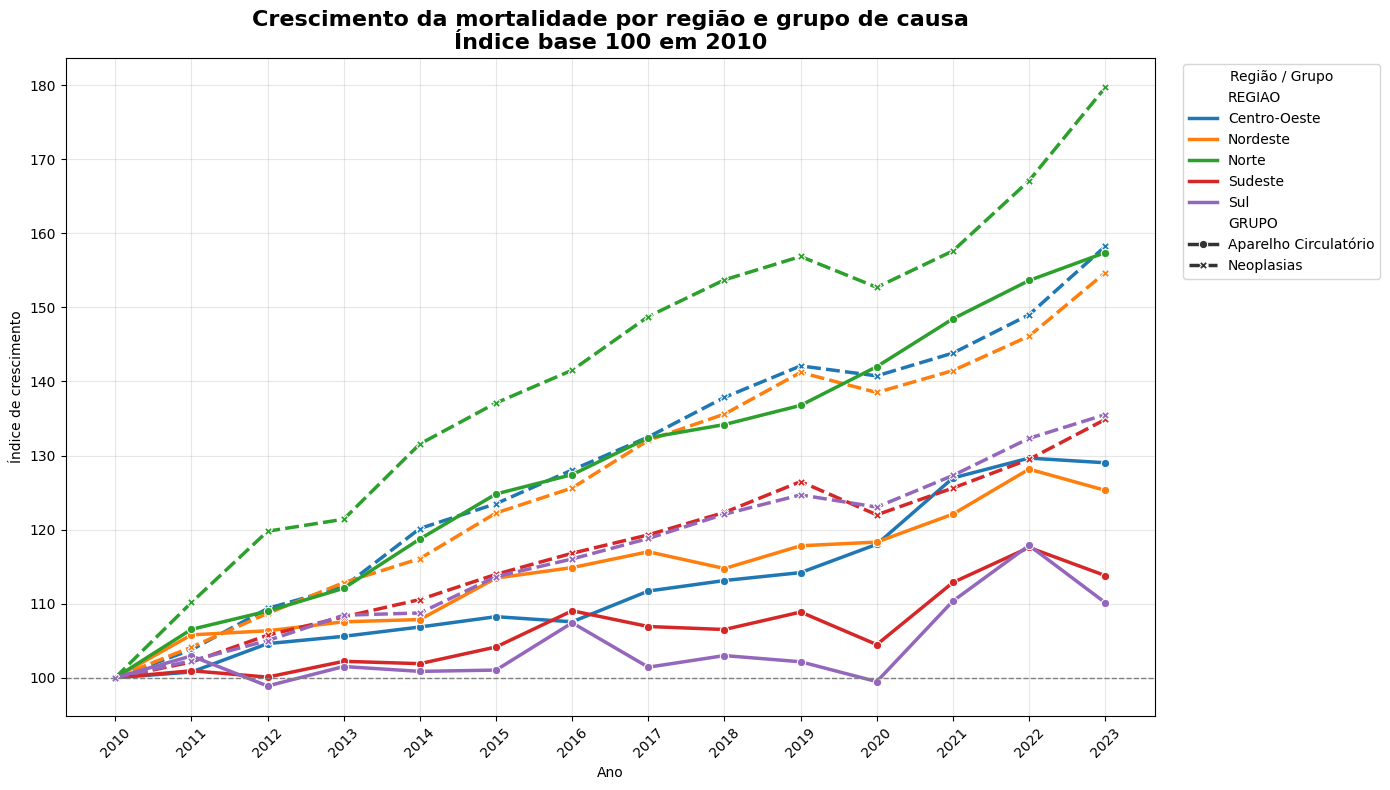

Figura salva em: /kaggle/working/outputs/figuras/crescimento_por_regiao_grupo.png


In [ ]:
plt.figure(figsize=(14, 8))

if sns:
    sns.lineplot(
        data=df_regiao_indice,
        x="ANO",
        y="INDICE_CRESCIMENTO",
        hue="REGIAO",
        style="GRUPO",
        markers=True,
        linewidth=2.5
    )
else:
    for (regiao, grupo), sub in df_regiao_indice.groupby(["REGIAO", "GRUPO"]):
        plt.plot(sub["ANO"], sub["INDICE_CRESCIMENTO"], marker="o", label=f"{regiao} - {grupo}")

plt.axhline(100, color="gray", linestyle="--", linewidth=1)
plt.title("Crescimento da mortalidade por região e grupo de causa\nÍndice base 100 em 2010", fontsize=16, fontweight="bold")
plt.xlabel("Ano")
plt.ylabel("Índice de crescimento")
plt.xticks(list(ANOS), rotation=45)
plt.grid(alpha=0.3)
plt.legend(title="Região / Grupo", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

arquivo = PASTA_FIGURAS / "crescimento_por_regiao_grupo.png"
plt.savefig(arquivo, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figura salva em: {arquivo}")

## 8. Ranking de crescimento acumulado por região em 2023

O ranking mostra quais regiões apresentaram maior variação percentual em relação a 2010.

In [ ]:
ranking_regiao_2023 = (
    df_regiao_indice[df_regiao_indice["ANO"] == 2023]
    .sort_values(["GRUPO", "VARIACAO_PERC"], ascending=[True, False])
    .reset_index(drop=True)
)

ranking_regiao_2023.to_csv(PASTA_SAIDA / "ranking_regiao_crescimento_2010_2023.csv", index=False)
display(ranking_regiao_2023)

,REGIAO,ANO,GRUPO,OBITOS,OBITOS_2010,INDICE_CRESCIMENTO,VARIACAO_PERC
0,Norte,2023,Aparelho Circulatório,22560,14333,157.399009,57.399009
1,Centro-Oeste,2023,Aparelho Circulatório,26222,20324,129.019878,29.019878
2,Nordeste,2023,Aparelho Circulatório,102356,81692,125.295011,25.295011
3,Sudeste,2023,Aparelho Circulatório,178646,157001,113.786536,13.786536
4,Sul,2023,Aparelho Circulatório,58393,53021,110.131835,10.131835
5,Norte,2023,Neoplasias,13858,7712,179.693983,79.693983
6,Centro-Oeste,2023,Neoplasias,17275,10917,158.239443,58.239443
7,Nordeste,2023,Neoplasias,57741,37330,154.677203,54.677203
8,Sul,2023,Neoplasias,47895,35340,135.526316,35.526316
9,Sudeste,2023,Neoplasias,118268,87691,134.869029,34.869029


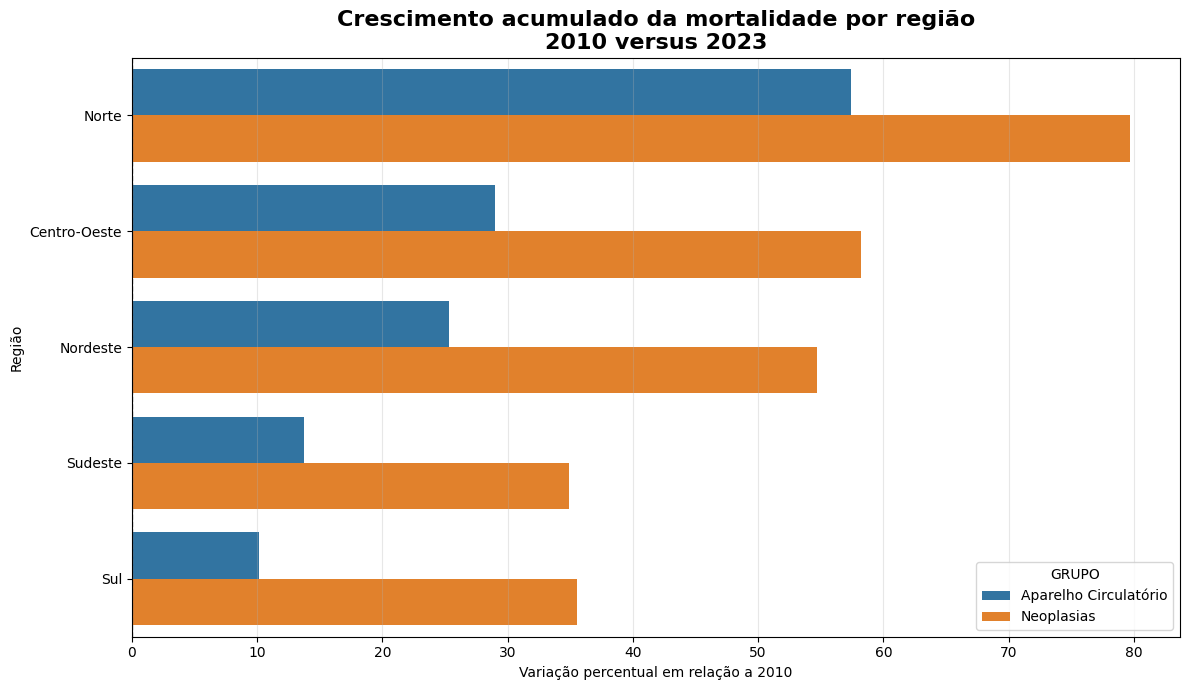

Figura salva em: /kaggle/working/outputs/figuras/ranking_regiao_2010_2023.png


In [ ]:
plt.figure(figsize=(12, 7))

if sns:
    sns.barplot(
        data=ranking_regiao_2023,
        x="VARIACAO_PERC",
        y="REGIAO",
        hue="GRUPO"
    )
else:
    pivot = ranking_regiao_2023.pivot(index="REGIAO", columns="GRUPO", values="VARIACAO_PERC")
    pivot.plot(kind="barh", figsize=(12,7))

plt.axvline(0, color="gray", linestyle="--", linewidth=1)
plt.title("Crescimento acumulado da mortalidade por região\n2010 versus 2023", fontsize=16, fontweight="bold")
plt.xlabel("Variação percentual em relação a 2010")
plt.ylabel("Região")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

arquivo = PASTA_FIGURAS / "ranking_regiao_2010_2023.png"
plt.savefig(arquivo, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figura salva em: {arquivo}")

## 9. Gráficos por UF

Mantém a visão estadual do notebook original, agora organizada em um único código.

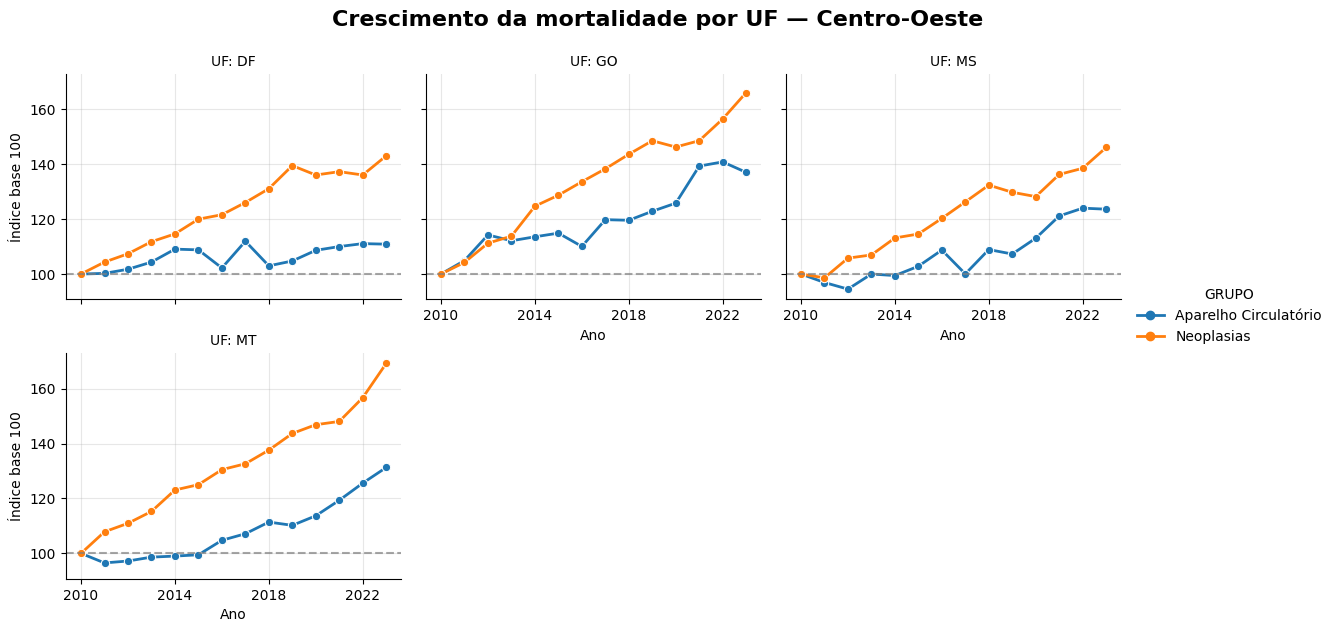

Figura salva em: /kaggle/working/outputs/figuras/crescimento_ufs_centro_oeste.png


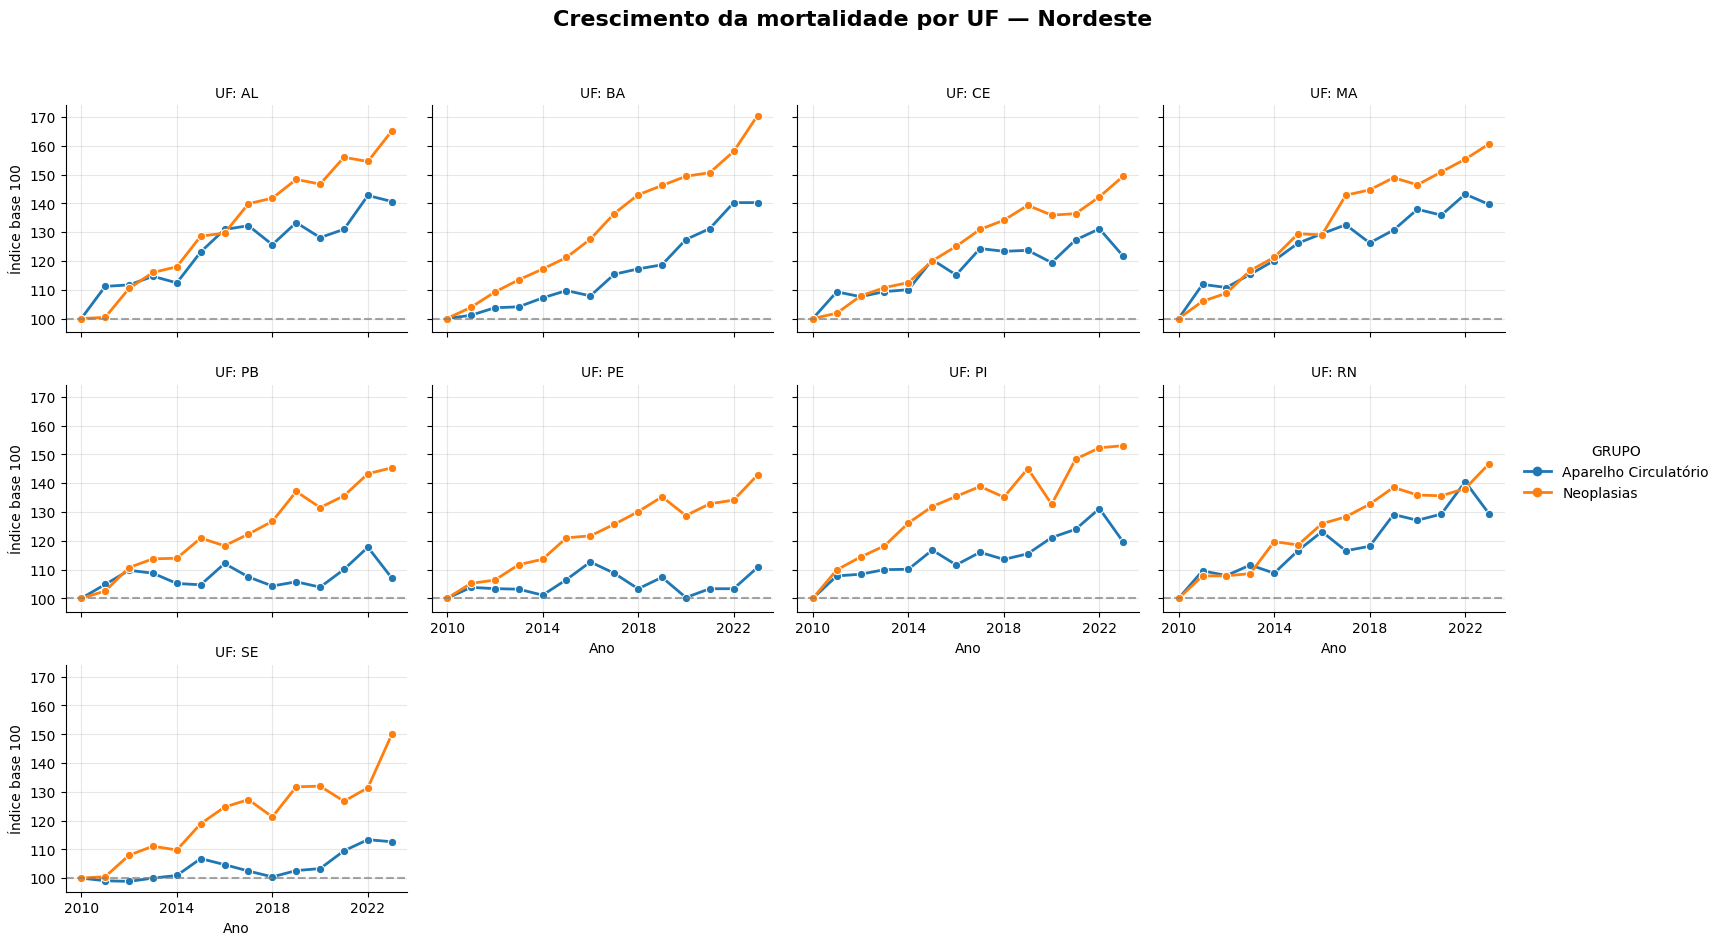

Figura salva em: /kaggle/working/outputs/figuras/crescimento_ufs_nordeste.png


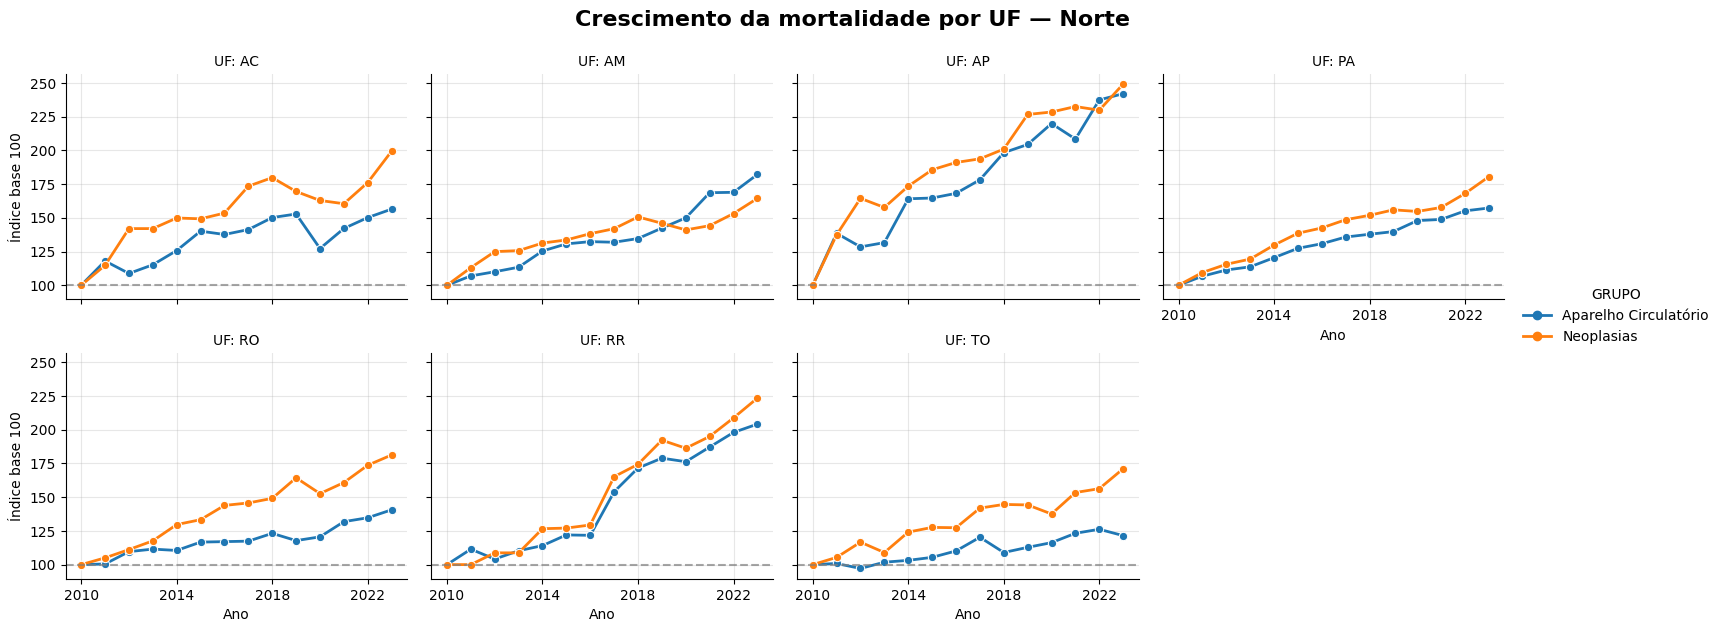

Figura salva em: /kaggle/working/outputs/figuras/crescimento_ufs_norte.png


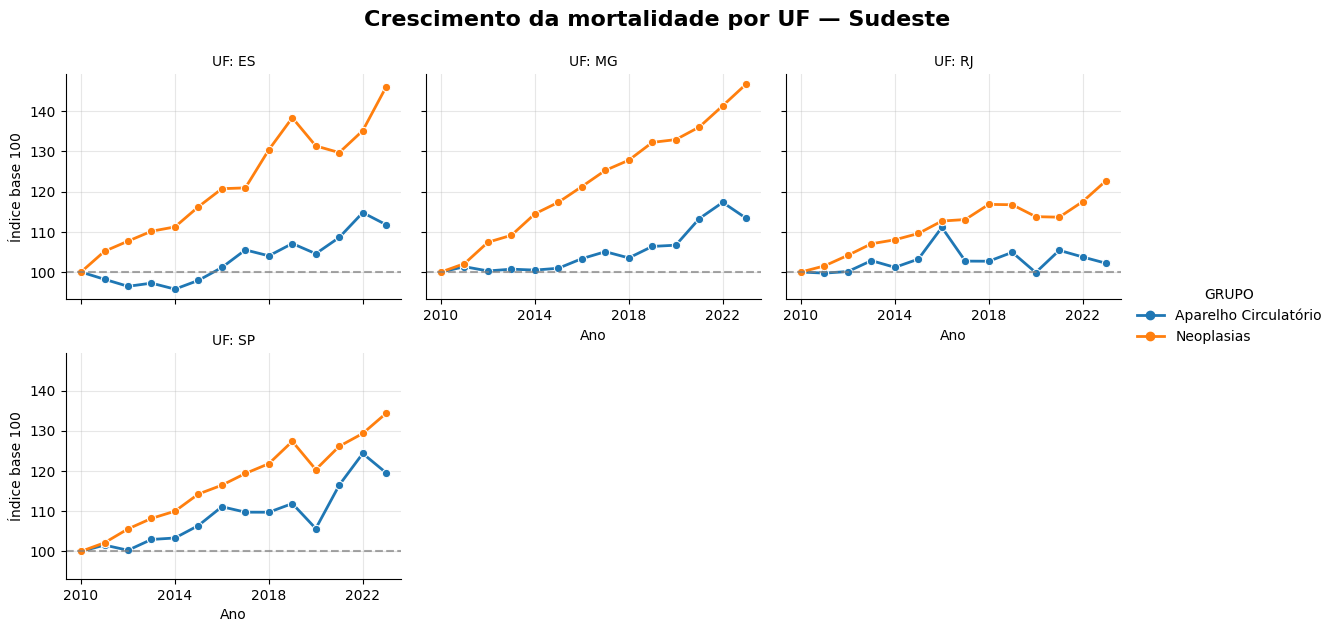

Figura salva em: /kaggle/working/outputs/figuras/crescimento_ufs_sudeste.png


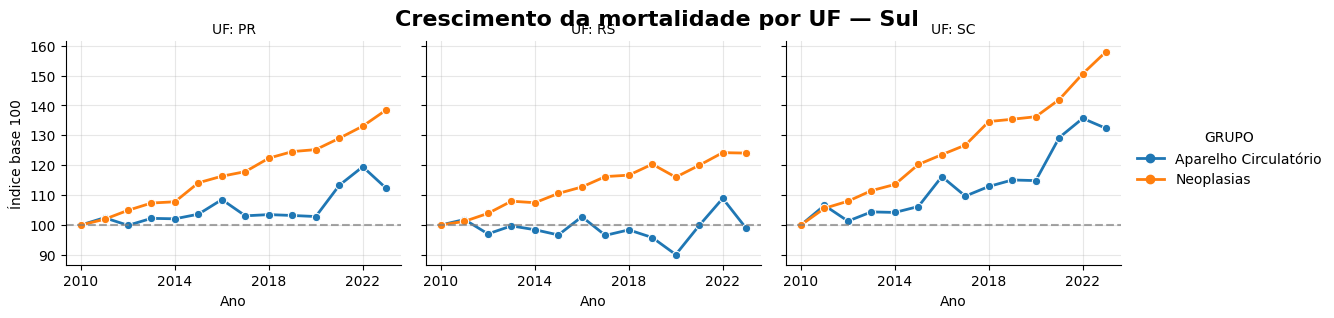

Figura salva em: /kaggle/working/outputs/figuras/crescimento_ufs_sul.png


In [ ]:
for regiao, df_reg in df_uf_indice.groupby("REGIAO"):
    n_ufs = df_reg["UF"].nunique()
    col_wrap = 3 if n_ufs <= 4 else 4

    if sns:
        g = sns.relplot(
            data=df_reg,
            x="ANO",
            y="INDICE_CRESCIMENTO",
            hue="GRUPO",
            col="UF",
            col_wrap=col_wrap,
            kind="line",
            marker="o",
            linewidth=2,
            height=3.2,
            aspect=1.2
        )
        g.set_titles("UF: {col_name}")
        g.set_axis_labels("Ano", "Índice base 100")
        for ax in g.axes.flat:
            ax.axhline(100, color="gray", linestyle="--", alpha=0.7)
            ax.grid(True, alpha=0.3)
            ax.set_xticks([2010, 2014, 2018, 2022])
        g.fig.suptitle(f"Crescimento da mortalidade por UF — {regiao}", fontsize=16, fontweight="bold")
        g.fig.subplots_adjust(top=0.88)
        arquivo = PASTA_FIGURAS / f"crescimento_ufs_{regiao.lower().replace('-', '_')}.png"
        plt.savefig(arquivo, dpi=300, bbox_inches="tight")
        plt.show()
        print(f"Figura salva em: {arquivo}")
    else:
        print("Seaborn não disponível; pulando gráfico facetado por UF.")

## 10. Ranking estadual em 2023

Mantém o ranking por UF, mas agora com a coluna `REGIAO`.

In [ ]:
ranking_uf_2023 = (
    df_uf_indice[df_uf_indice["ANO"] == 2023]
    .sort_values(["GRUPO", "VARIACAO_PERC"], ascending=[True, False])
    .reset_index(drop=True)
)

ranking_uf_2023.to_csv(PASTA_SAIDA / "ranking_uf_crescimento_2010_2023.csv", index=False)
display(ranking_uf_2023.head(30))

print("\nResumo textual do ranking:")
for grupo in ranking_uf_2023["GRUPO"].unique():
    print(f"\nGrupo: {grupo}")
    tmp = ranking_uf_2023[ranking_uf_2023["GRUPO"] == grupo].head(10)
    for _, row in tmp.iterrows():
        print(f"{row['UF']} ({row['REGIAO']}): {row['VARIACAO_PERC']:.1f}% | {int(row['OBITOS_2010'])} -> {int(row['OBITOS'])}")

,REGIAO,UF,ANO,GRUPO,OBITOS,OBITOS_2010,INDICE_CRESCIMENTO,VARIACAO_PERC
0,Norte,AP,2023,Aparelho Circulatório,842,348,241.954023,141.954023
1,Norte,RR,2023,Aparelho Circulatório,696,341,204.105572,104.105572
2,Norte,AM,2023,Aparelho Circulatório,4331,2378,182.127839,82.127839
3,Norte,PA,2023,Aparelho Circulatório,10851,6900,157.260870,57.260870
4,Norte,AC,2023,Aparelho Circulatório,948,606,156.435644,56.435644
5,Nordeste,AL,2023,Aparelho Circulatório,6632,4715,140.657476,40.657476
6,Norte,RO,2023,Aparelho Circulatório,2386,1697,140.601061,40.601061
7,Nordeste,BA,2023,Aparelho Circulatório,26528,18911,140.278145,40.278145
8,Nordeste,MA,2023,Aparelho Circulatório,11455,8204,139.627011,39.627011
9,Centro-Oeste,GO,2023,Aparelho Circulatório,11991,8752,137.008684,37.008684



Resumo textual do ranking:

Grupo: Aparelho Circulatório
AP (Norte): 142.0% | 348 -> 842
RR (Norte): 104.1% | 341 -> 696
AM (Norte): 82.1% | 2378 -> 4331
PA (Norte): 57.3% | 6900 -> 10851
AC (Norte): 56.4% | 606 -> 948
AL (Nordeste): 40.7% | 4715 -> 6632
RO (Norte): 40.6% | 1697 -> 2386
BA (Nordeste): 40.3% | 18911 -> 26528
MA (Nordeste): 39.6% | 8204 -> 11455
GO (Centro-Oeste): 37.0% | 8752 -> 11991

Grupo: Neoplasias
AP (Norte): 149.1% | 222 -> 553
RR (Norte): 123.4% | 218 -> 487
AC (Norte): 99.4% | 331 -> 660
RO (Norte): 81.2% | 880 -> 1595
PA (Norte): 80.5% | 3386 -> 6112
TO (Norte): 71.1% | 805 -> 1377
BA (Nordeste): 70.5% | 9168 -> 15635
MT (Centro-Oeste): 69.2% | 2011 -> 3402
GO (Centro-Oeste): 66.1% | 4628 -> 7686
AL (Nordeste): 65.2% | 1719 -> 2839


## 11. Arquivos gerados

Ao final, os principais arquivos estarão em `/kaggle/working/outputs/`:

- `mortalidade_uf_consolidado.csv`
- `mortalidade_regiao_consolidado.csv`
- `mortalidade_uf_indice_base2010.csv`
- `mortalidade_regiao_indice_base2010.csv`
- `ranking_regiao_crescimento_2010_2023.csv`
- `ranking_uf_crescimento_2010_2023.csv`
- `logs_processamento.csv`
- `arquivos_ausentes_ou_com_erro.csv`
- pasta `figuras/` com gráficos em PNG 300 dpi.

In [ ]:
print("Arquivos em outputs:")
for caminho in sorted(PASTA_SAIDA.rglob("*")):
    print(caminho)

Arquivos em outputs:
/kaggle/working/outputs/arquivos_ausentes_ou_com_erro.csv
/kaggle/working/outputs/figuras
/kaggle/working/outputs/figuras/crescimento_por_regiao_grupo.png
/kaggle/working/outputs/figuras/crescimento_ufs_centro_oeste.png
/kaggle/working/outputs/figuras/crescimento_ufs_nordeste.png
/kaggle/working/outputs/figuras/crescimento_ufs_norte.png
/kaggle/working/outputs/figuras/crescimento_ufs_sudeste.png
/kaggle/working/outputs/figuras/crescimento_ufs_sul.png
/kaggle/working/outputs/figuras/ranking_regiao_2010_2023.png
/kaggle/working/outputs/logs_processamento.csv
/kaggle/working/outputs/mortalidade_regiao_consolidado.csv
/kaggle/working/outputs/mortalidade_regiao_indice_base2010.csv
/kaggle/working/outputs/mortalidade_uf_consolidado.csv
/kaggle/working/outputs/mortalidade_uf_indice_base2010.csv
/kaggle/working/outputs/ranking_regiao_crescimento_2010_2023.csv
/kaggle/working/outputs/ranking_uf_crescimento_2010_2023.csv


## Observação metodológica importante

Este notebook utiliza número absoluto de óbitos e índice de crescimento com base 100 em 2010.  
Para um artigo científico, a etapa seguinte deve incluir população por ano/UF e padronização por idade, especialmente porque neoplasias e doenças cardiovasculares são fortemente influenciadas pelo envelhecimento populacional.